In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



Data collection and info


In [2]:
student=pd.read_csv("C:/Users/mahes/Downloads/archive (2).zip")
student


,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,23,Male,3rd Year,3.0,0,178,Gemini,NaN,6,...,5,8.1,19.2,8.3,1.9,1.0,10,49.7,1,Low
7996,7997,21,Other,1st Year,3.3,0,63,Claude,Exam Prep,10,...,6,5.7,3.0,5.0,1.3,2.9,5,58.4,1,Medium
7997,7998,24,Male,3rd Year,1.6,0,113,ChatGPT,Coding,5,...,6,4.5,-18.0,5.0,3.5,0.1,9,69.1,1,Medium
7998,7999,22,Female,2nd Year,5.5,0,21,Copilot,Coding,5,...,8,3.4,-19.1,4.7,5.9,0.4,7,49.2,1,Low


In [3]:
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       8000 non-null   int64  
 1   age                              8000 non-null   int64  
 2   gender                           8000 non-null   object 
 3   grade_level                      8000 non-null   object 
 4   study_hours_per_day              8000 non-null   float64
 5   uses_ai                          8000 non-null   int64  
 6   ai_usage_time_minutes            8000 non-null   int64  
 7   ai_tools_used                    6638 non-null   object 
 8   ai_usage_purpose                 6654 non-null   object 
 9   ai_dependency_score              8000 non-null   int64  
 10  ai_generated_content_percentage  8000 non-null   int64  
 11  ai_prompts_per_week              8000 non-null   int64  
 12  ai_ethics_score     

In [4]:
student.describe()

,student_id,age,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,...,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed
count,8000.00000,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,...,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,18.96725,3.286938,0.641000,88.989875,5.515125,50.057500,59.359500,5.472375,59.501250,...,69.852112,5.484750,5.516450,10.127325,6.465025,3.010600,2.523387,5.463375,56.811988,0.889250
std,2309.54541,3.15316,1.582171,0.479737,52.184077,2.883064,29.440109,34.869496,2.872067,23.161888,...,17.234339,2.898546,2.586377,17.479288,1.435670,1.744974,1.436991,2.881917,13.455724,0.313842
min,1.00000,14.00000,0.500000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,20.000000,...,40.000000,1.000000,1.000000,-20.000000,4.000000,0.000000,0.000000,1.000000,12.700000,0.000000
25%,2000.75000,16.00000,1.900000,0.000000,43.000000,3.000000,25.000000,29.000000,3.000000,39.750000,...,54.800000,3.000000,3.200000,-5.000000,5.200000,1.500000,1.300000,3.000000,47.300000,1.000000
50%,4000.50000,19.00000,3.300000,1.000000,89.000000,6.000000,50.000000,59.000000,6.000000,59.000000,...,70.000000,5.000000,5.500000,10.150000,6.400000,3.000000,2.500000,5.000000,56.900000,1.000000
75%,6000.25000,22.00000,4.600000,1.000000,134.000000,8.000000,76.000000,90.000000,8.000000,80.000000,...,84.600000,8.000000,7.800000,25.500000,7.700000,4.500000,3.800000,8.000000,66.200000,1.000000
max,8000.00000,24.00000,6.000000,1.000000,179.000000,10.000000,100.000000,119.000000,10.000000,99.000000,...,100.000000,10.000000,10.000000,40.000000,9.000000,6.000000,5.000000,10.000000,95.800000,1.000000


In [5]:
student.isnull().sum()

student_id                            0
age                                   0
gender                                0
grade_level                           0
study_hours_per_day                   0
uses_ai                               0
ai_usage_time_minutes                 0
ai_tools_used                      1362
ai_usage_purpose                   1346
ai_dependency_score                   0
ai_generated_content_percentage       0
ai_prompts_per_week                   0
ai_ethics_score                       0
last_exam_score                       0
assignment_scores_avg                 0
attendance_percentage                 0
concept_understanding_score           0
study_consistency_index               0
improvement_rate                      0
sleep_hours                           0
social_media_hours                    0
tutoring_hours                        0
class_participation_score             0
final_score                           0
passed                                0


In [6]:
student.duplicated().sum()

np.int64(0)

In [32]:
print(student["gender"].unique())
print(student["grade_level"].unique())
print(student["ai_tools_used"].unique())
print(student["ai_usage_purpose"].unique())
print(student["performance_category"].unique())

['Female' 'Male' 'Other']
['1st Year' '12th' '3rd Year' '10th' '11th' '2nd Year']
[nan 'Copilot' 'ChatGPT+Gemini' 'ChatGPT' 'Gemini' 'Claude']
['Exam Prep' 'Notes' 'Doubt Solving' 'Coding' nan 'Homework']
['Low' 'Medium' 'High']


Class Imbalance


In [22]:

print(((student["performance_category"]=='Low')==True).sum())
print(((student["performance_category"]=='Medium')==True).sum())
print(((student["performance_category"]=='High')==True).sum())

2542
4705
753


EDA(Data Visualization)

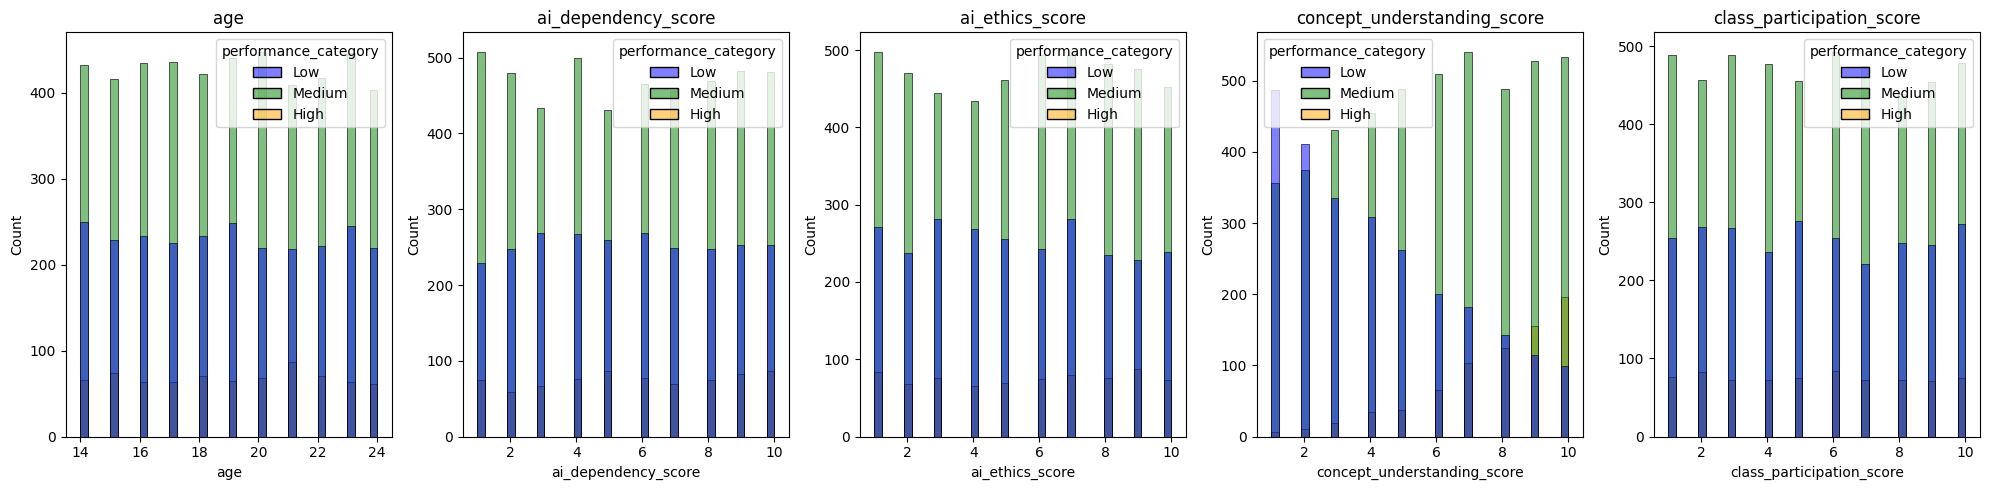

In [5]:


cols = ['age','ai_dependency_score','ai_ethics_score','concept_understanding_score','class_participation_score']
                    
palette = {
    'Low': 'blue',
    'Medium': 'green',
    'High': 'orange'
}
plt.figure(figsize=(4 * len(cols), 5))

for i, col in enumerate(cols):
 plt.subplot(1, len(cols), i + 1)
 sns.histplot(data=student,x=col,hue="performance_category", bins=40,palette=palette)
 plt.title(col)
 plt.xlabel(col)
 plt.ylabel('Count')

plt.tight_layout()
plt.show()


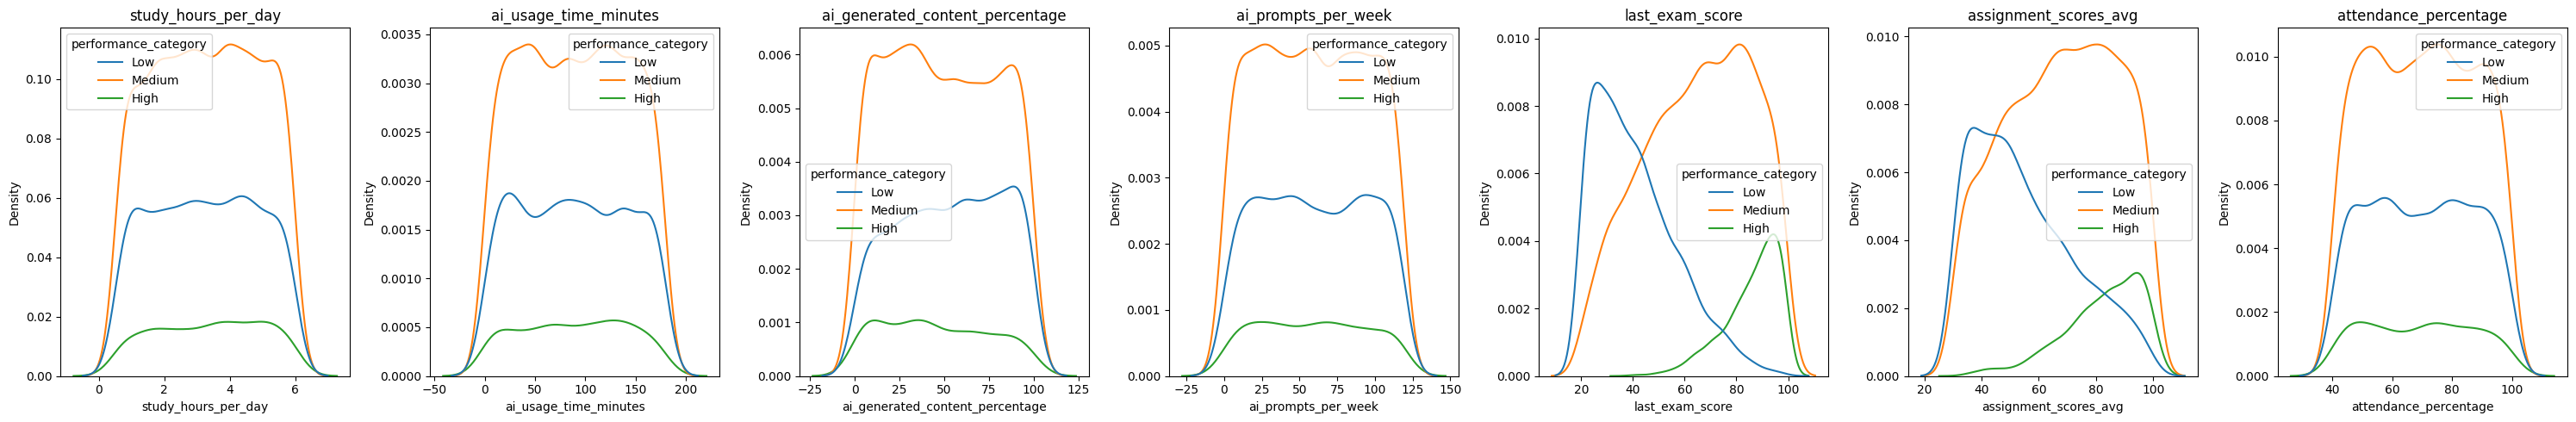

In [6]:

col1=['study_hours_per_day','ai_usage_time_minutes','ai_generated_content_percentage','ai_prompts_per_week','last_exam_score',  
'assignment_scores_avg','attendance_percentage']
plt.figure(figsize=(6* len(cols), 5))


for i, col11 in enumerate(col1):
    ax=plt.subplot(1, len(col1), i + 1)
    sns.kdeplot(data=student,x=col11,hue="performance_category")
    plt.title(col11)
    plt.xlabel(col11)
    
   

plt.tight_layout()
plt.show()

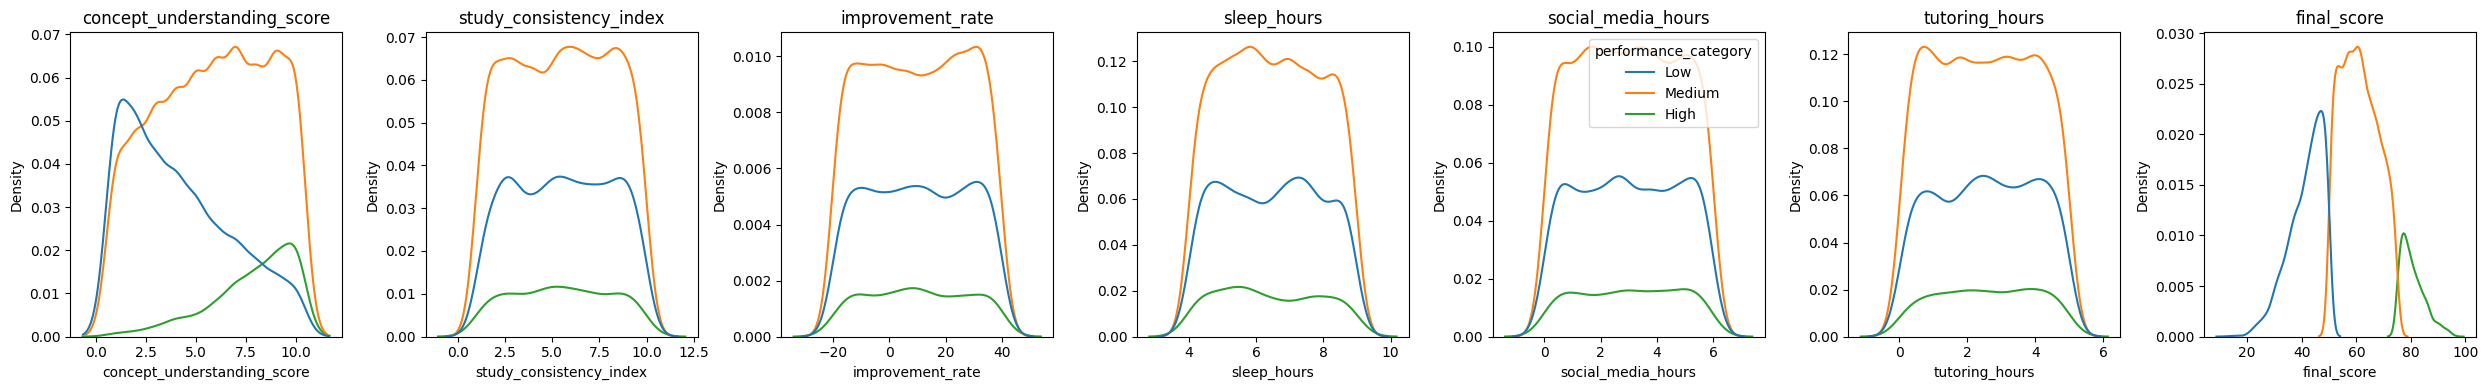

In [125]:

col1=['concept_understanding_score' ,'study_consistency_index' ,
'improvement_rate' ,'sleep_hours','social_media_hours','tutoring_hours','final_score']
plt.figure(figsize=(5* len(cols), 4))


for i, col11 in enumerate(col1):
    ax=plt.subplot(1, len(col1), i + 1)
    sns.kdeplot(data=student,x=col11,hue="performance_category")
    plt.title(col11)
    plt.xlabel(col11)
    if i != len(cols) - 1:
           ax.legend_.remove() 

plt.tight_layout()
plt.show()

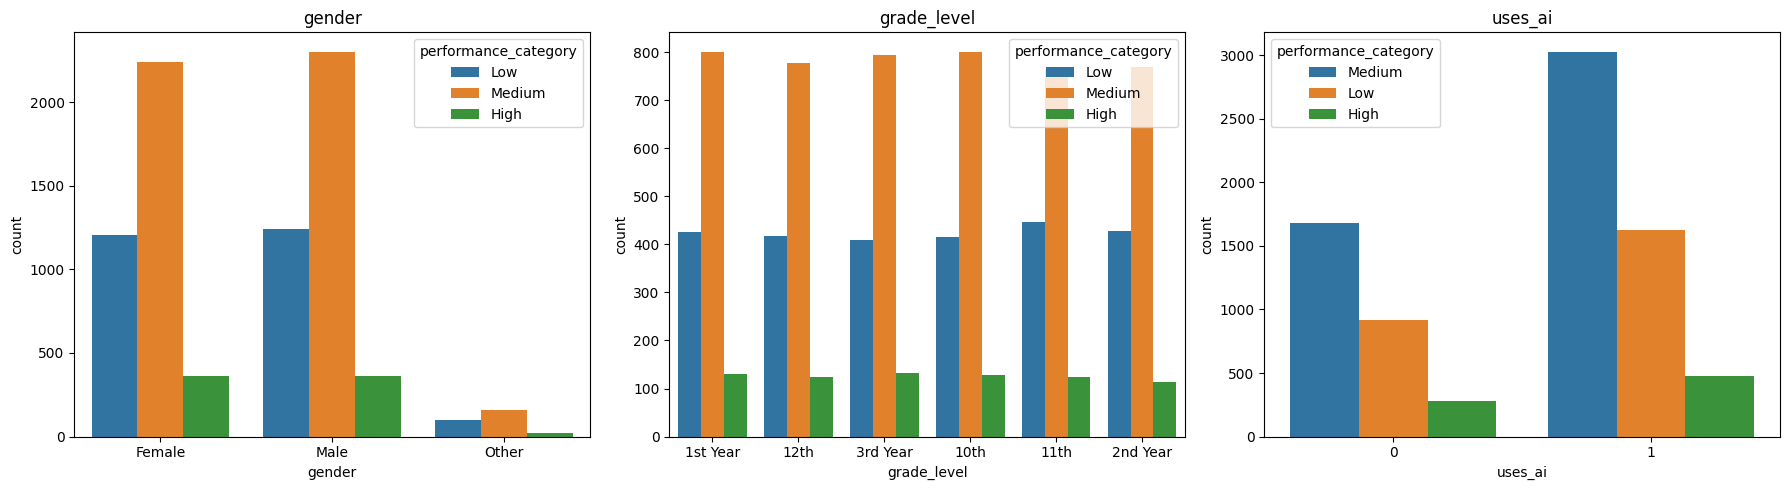

In [7]:
col=['gender','grade_level','uses_ai']
plt.figure(figsize=(6*len(col),5))

for i,col1 in enumerate(col):
    plt.subplot(1,len(col),i+1)
    sns.countplot(data=student,x=col1,hue="performance_category")
    plt.title(col[i])


plt.tight_layout()
plt.show()

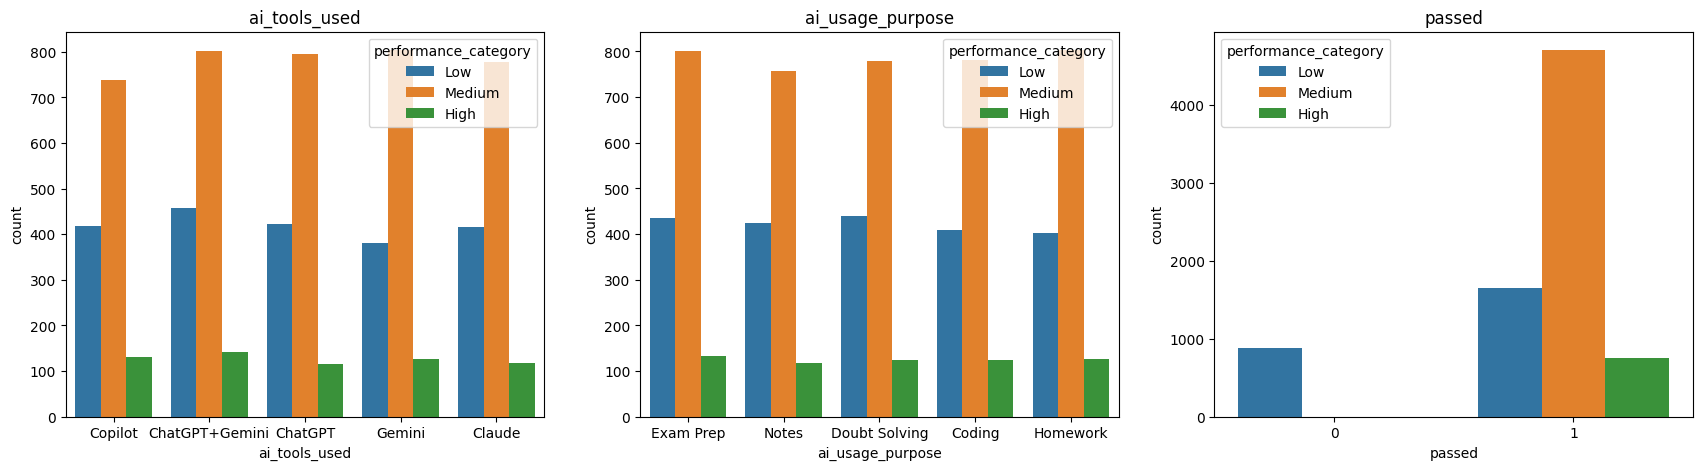

In [150]:
col=['ai_tools_used','ai_usage_purpose','passed']
plt.figure(figsize=(7*len(col),5))

for i,c in enumerate(col):
    ax=plt.subplot(1,len(col),i+1)
    sns.countplot(data=student,x=c,hue="performance_category")
    plt.title(col[i])
   
 

plt.show()

HANDLING NULL VALUES 

In [5]:
value=student["ai_tools_used"].mode()[0]
student["ai_tools_used"].fillna(value,inplace=True)
value2=student["ai_usage_purpose"].mode()[0]
student["ai_usage_purpose"].fillna(value2,inplace=True)

C:\Users\mahes\AppData\Local\Temp\ipykernel_27996\885464325.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  student["ai_tools_used"].fillna(value,inplace=True)
C:\Users\mahes\AppData\Local\Temp\ipykernel_27996\885464325.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

OUTLIERS

:Only a small number of outliers are detected in column final score that can be neglected

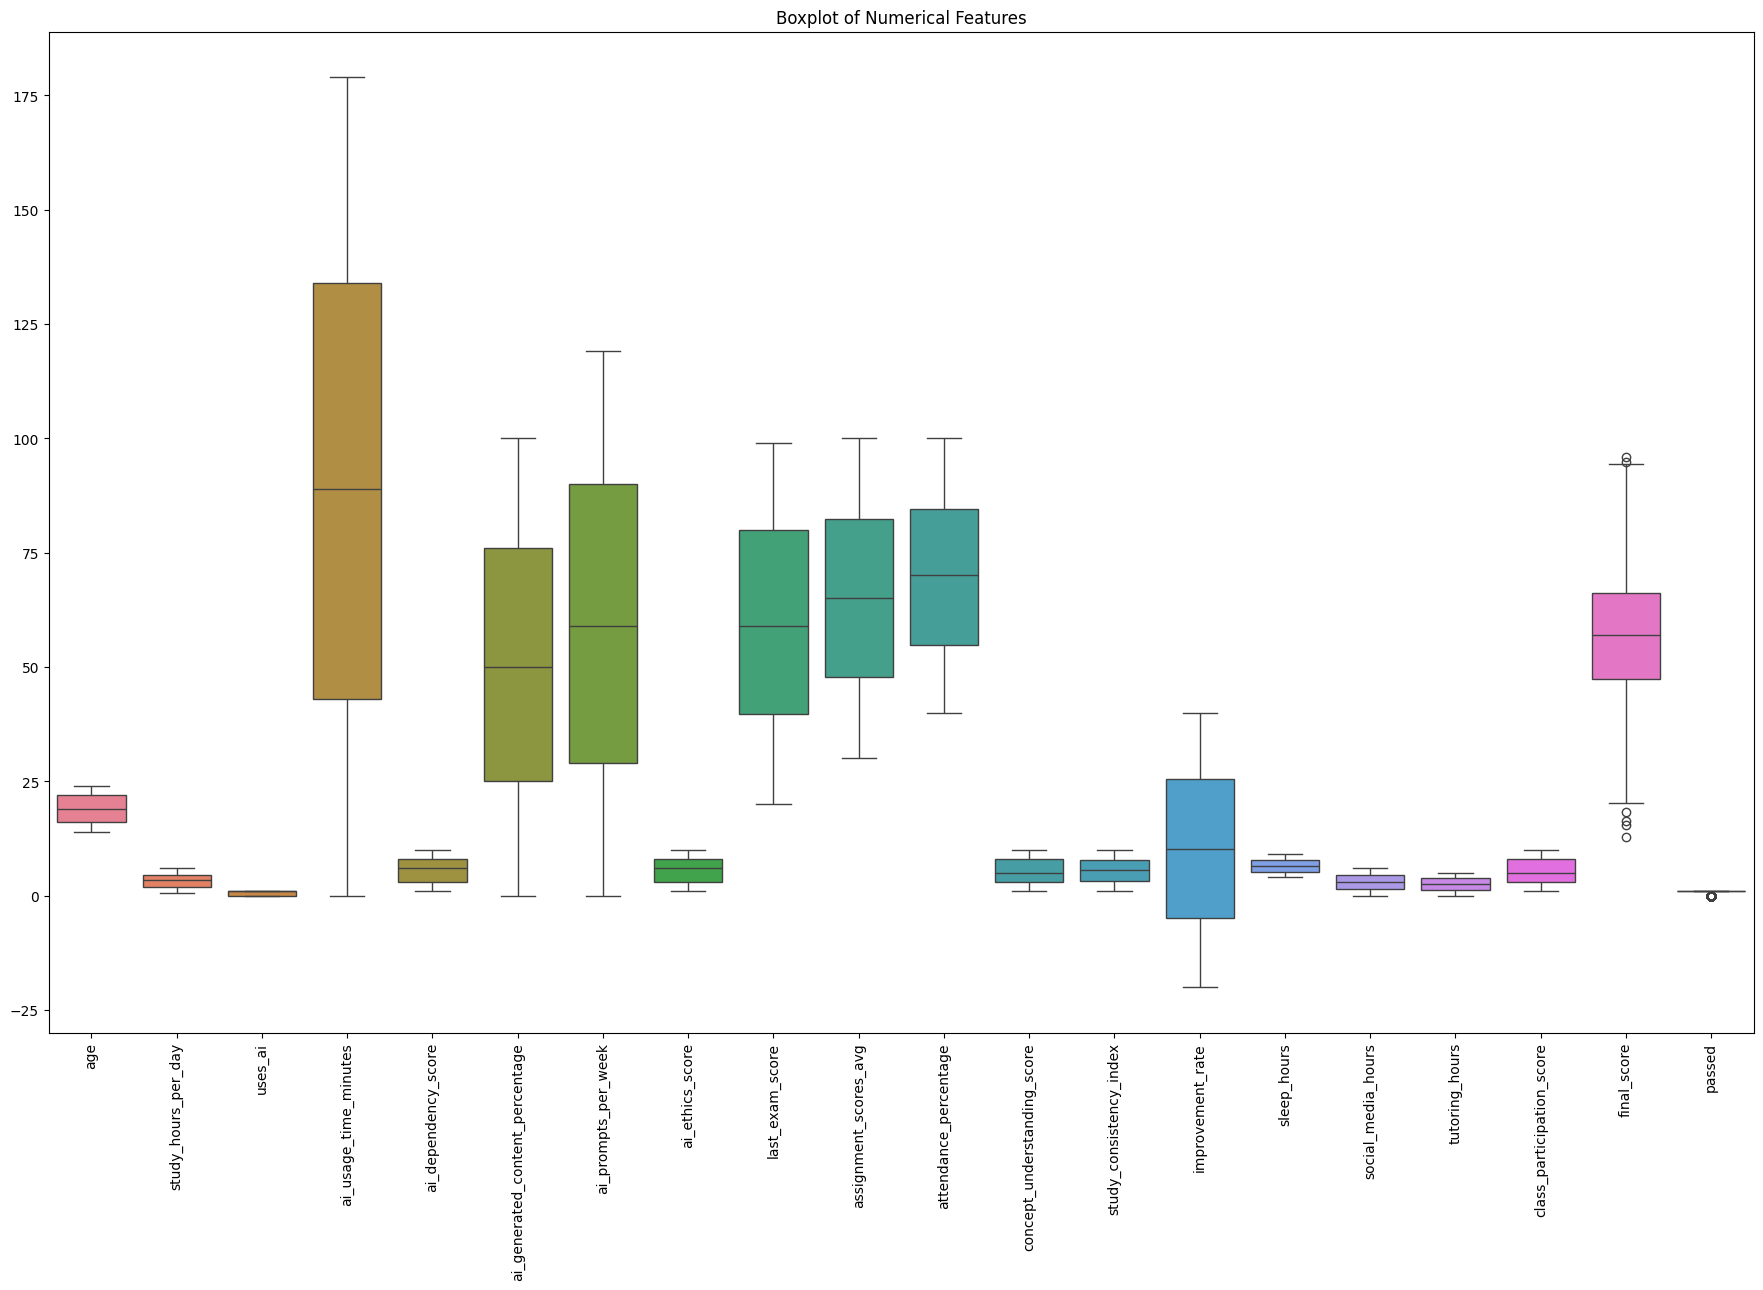

In [9]:
numerical_features = ["age", "study_hours_per_day", "uses_ai", "ai_usage_time_minutes",
                      "ai_dependency_score", "ai_generated_content_percentage", "ai_prompts_per_week",
                      "ai_ethics_score", "last_exam_score", "assignment_scores_avg", "attendance_percentage",
                      "concept_understanding_score", "study_consistency_index", "improvement_rate",
                      "sleep_hours", "social_media_hours", "tutoring_hours",
                      "class_participation_score", "final_score", "passed"]

plt.figure(figsize=(22,13))
sns.boxplot(data=student[numerical_features])
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.show()

ENCODING CATEGORICAL COLUMNS

In [6]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ["gender","grade_level","ai_tools_used","ai_usage_purpose"]
target_col = "performance_category"

student_final = student.copy()

le = LabelEncoder()
for col in cat_cols:
    student_final[col] = le.fit_transform(student_final[col])


student_final[target_col] = le.fit_transform(student_final[target_col])

print(student_final.head())
print("\nShape:", student_final.shape)




   student_id  age  gender  grade_level  study_hours_per_day  uses_ai  \
0           1   20       0            3                  2.5        1   
1           2   17       1            2                  3.4        1   
2           3   24       1            5                  0.8        0   
3           4   21       0            2                  4.4        0   
4           5   18       2            5                  3.5        1   

   ai_usage_time_minutes  ai_tools_used  ai_usage_purpose  \
0                    170              1                 2   
1                    123              1                 4   
2                     35              3                 1   
3                     45              1                 4   
4                     21              1                 0   

   ai_dependency_score  ...  concept_understanding_score  \
0                   10  ...                            4   
1                    4  ...                            8   
2             

In [8]:
student_final

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,0,3,2.5,1,170,5,2,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,1
1,2,17,1,2,3.4,1,123,5,4,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,2
2,3,24,1,5,0.8,0,35,3,1,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,2
3,4,21,0,2,4.4,0,45,1,4,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,2
4,5,18,2,5,3.5,1,21,1,0,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,23,1,5,3.0,0,178,4,5,6,...,5,8.1,19.2,8.3,1.9,1.0,10,49.7,1,1
7996,7997,21,2,3,3.3,0,63,2,2,10,...,6,5.7,3.0,5.0,1.3,2.9,5,58.4,1,2
7997,7998,24,1,5,1.6,0,113,0,0,5,...,6,4.5,-18.0,5.0,3.5,0.1,9,69.1,1,2
7998,7999,22,0,4,5.5,0,21,3,0,5,...,8,3.4,-19.1,4.7,5.9,0.4,7,49.2,1,1



0->high,1-Low,2->medium

In [7]:
student_final=student_final.drop(columns="student_id")

CORRELATION

<Axes: >

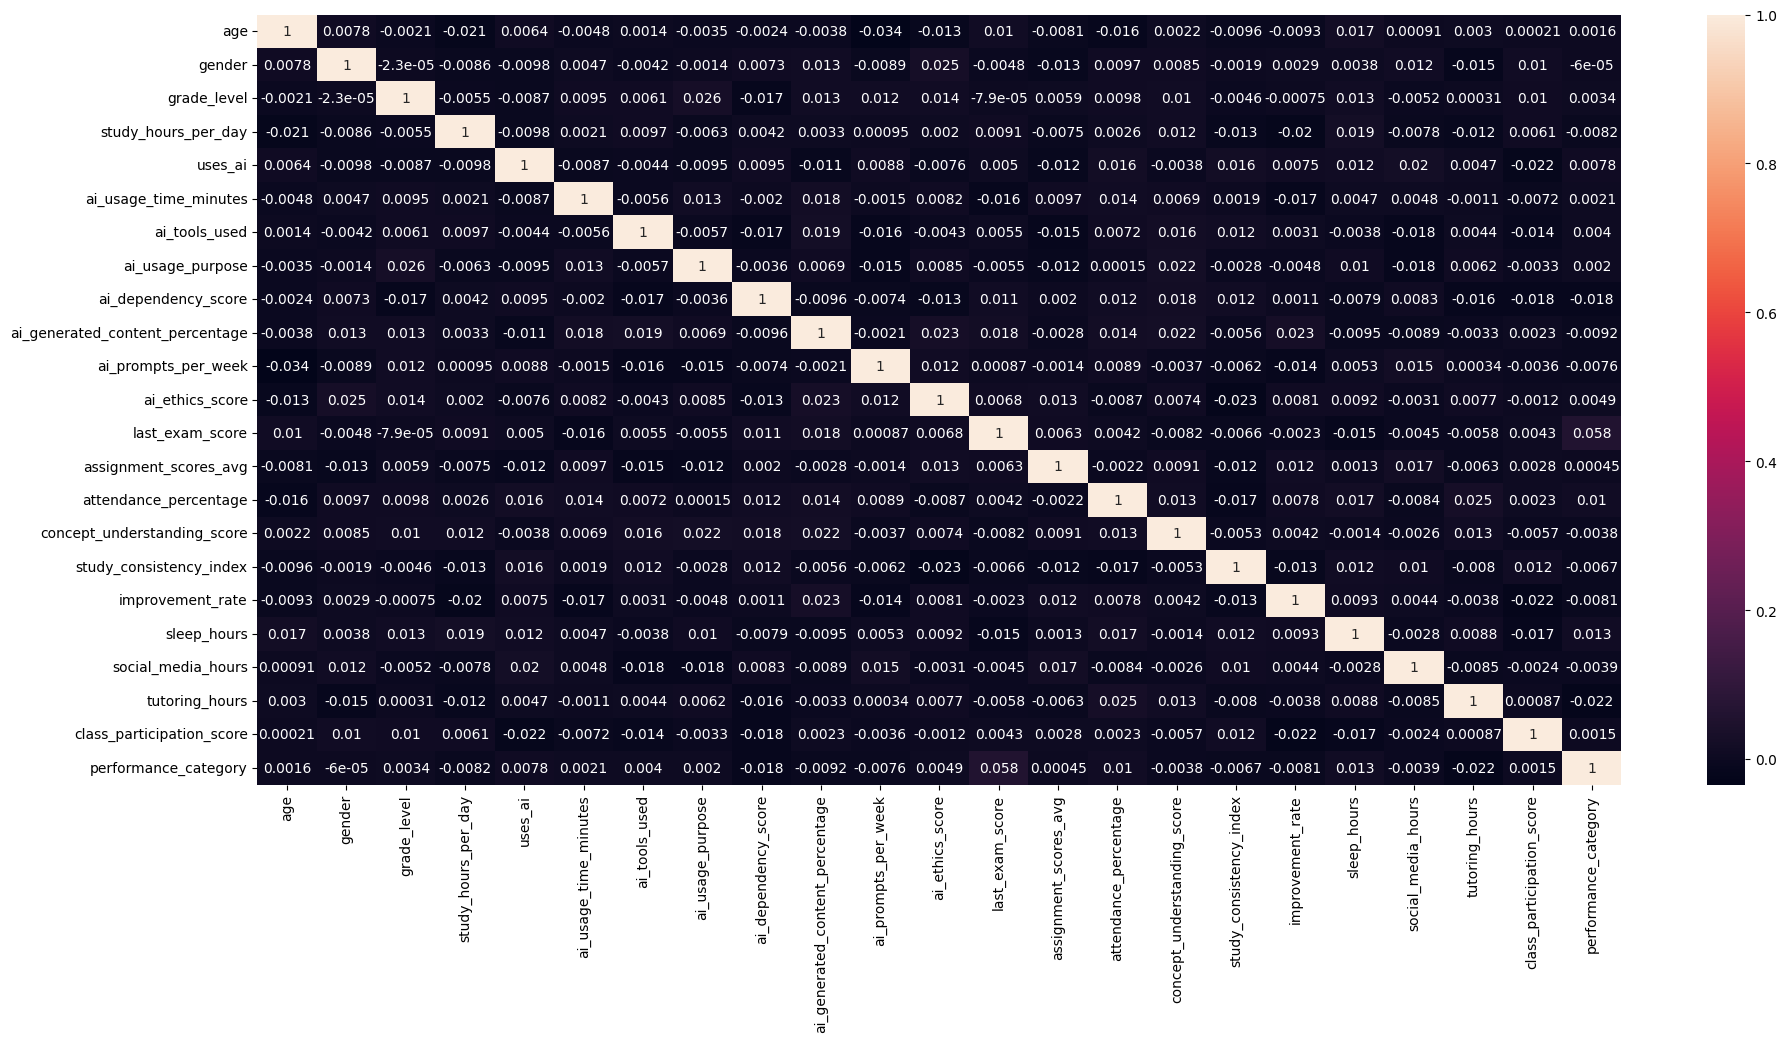

In [37]:
plt.figure(figsize=(22,10))
sns.heatmap(student_final.corr(),annot=True)

TRAINING,TESTING AND SPLITTING

: 80 % of dataset has been taken for training while 20 % for testing 

In [8]:
student_final=student_final.drop(columns="passed")

In [9]:
student_final=student_final.drop(columns="final_score")

In [10]:
from sklearn.model_selection import train_test_split
x=student_final.drop(columns="performance_category")
y=student_final["performance_category"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)
    

In [10]:
x_train.shape

(6400, 22)

In [19]:
x_test.shape

(1600, 22)

STANDARD SCALING 

In [11]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

MODEL TRAINING




Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(class_weight="balanced")
lr.fit(x_train,y_train)
lr_train=lr.score(x_train,y_train)
lr_test=lr.score(x_test,y_test)
print("Training accuracy :",lr_train)
print("Testing accuracy :",lr_test)

Training accuracy : 0.81640625
Testing accuracy : 0.820625


In [13]:
from sklearn.metrics import classification_report
y_pred_lr = lr.predict(x_test)
print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.55      0.91      0.68       151
           1       0.80      0.92      0.85       508
           2       0.93      0.75      0.83       941

    accuracy                           0.82      1600
   macro avg       0.76      0.86      0.79      1600
weighted avg       0.85      0.82      0.82      1600



DecisionTreeClassifier

In [34]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(class_weight="balanced")
dt.fit(x_train,y_train)
dt_train=dt.score(x_train,y_train)
dt_test=dt.score(x_test,y_test)
print("Training accuracy :",dt_train)
print("Testing accuracy :",dt_test)


Training accuracy : 1.0
Testing accuracy : 0.76375


In [26]:
y_pred_dt = dt.predict(x_test)
print(classification_report(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       0.61      0.63      0.62       151
           1       0.74      0.76      0.75       508
           2       0.81      0.79      0.80       941

    accuracy                           0.77      1600
   macro avg       0.72      0.73      0.72      1600
weighted avg       0.77      0.77      0.77      1600



SupportVectorClassifier

In [35]:
from sklearn.svm import SVC
sv=SVC(class_weight="balanced")
sv.fit(x_train,y_train)
sv_train=sv.score(x_train,y_train)
sv_test=sv.score(x_test,y_test)
print("Training accuracy :",sv_train)
print("Testing accuracy :",sv_test)


Training accuracy : 0.8821875
Testing accuracy : 0.814375


In [17]:
y_pred_sv = sv.predict(x_test)
print(classification_report(y_test, y_pred_sv))


              precision    recall  f1-score   support

           0       0.56      0.83      0.66       151
           1       0.79      0.89      0.84       508
           2       0.90      0.76      0.83       941

    accuracy                           0.81      1600
   macro avg       0.75      0.83      0.78      1600
weighted avg       0.83      0.81      0.81      1600



KNearestNeighbors classifier

In [36]:
from sklearn.neighbors import KNeighborsClassifier
kn=KNeighborsClassifier()
kn.fit(x_train,y_train)
kn_train=kn.score(x_train,y_train)
kn_test=kn.score(x_test,y_test)
print("Training accuracy :",kn_train)
print("Testing accuracy :",kn_test)



Training accuracy : 0.80125
Testing accuracy : 0.703125


In [29]:
y_pred_kn = kn.predict(x_test)
print(classification_report(y_test, y_pred_kn))

              precision    recall  f1-score   support

           0       0.52      0.23      0.32       159
           1       0.71      0.56      0.62       545
           2       0.67      0.83      0.74       896

    accuracy                           0.68      1600
   macro avg       0.63      0.54      0.56      1600
weighted avg       0.67      0.68      0.66      1600



RandomForest 

In [37]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
rf_train=rf.score(x_train,y_train)
rf_test=rf.score(x_test,y_test)
print("Training accuracy :",rf_train)
print("Testing accuracy :",rf_test)



Training accuracy : 1.0
Testing accuracy : 0.82625


In [32]:
y_pred_rf = rf.predict(x_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.43      0.59       159
           1       0.88      0.77      0.82       545
           2       0.79      0.93      0.86       896

    accuracy                           0.83      1600
   macro avg       0.86      0.71      0.76      1600
weighted avg       0.84      0.83      0.82      1600



GaussianNB Classifier


In [38]:
from sklearn.naive_bayes import GaussianNB
gb=GaussianNB()
gb.fit(x_train,y_train)
gb_train=gb.score(x_train,y_train)
gb_test=gb.score(x_test,y_test)
print("Training accuracy :",gb_train)
print("Testing accuracy :",gb_test)


Training accuracy : 0.82578125
Testing accuracy : 0.826875


In [34]:
y_pred_gb = gb.predict(x_test)
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.88      0.45      0.60       159
           1       0.90      0.73      0.81       545
           2       0.78      0.94      0.86       896

    accuracy                           0.82      1600
   macro avg       0.86      0.71      0.75      1600
weighted avg       0.83      0.82      0.81      1600



BOOSTING METHODS

ADABOOST


In [39]:
from sklearn.ensemble import AdaBoostClassifier
ad=AdaBoostClassifier()
ad.fit(x_train,y_train)
ad_train=ad.score(x_train,y_train)
ad_test=ad.score(x_test,y_test)
print("Training accuracy :",ad_train)
print("Testing accuracy :",ad_test)


Training accuracy : 0.8153125
Testing accuracy : 0.815


In [36]:
y_pred_ad = ad.predict(x_test)
print(classification_report(y_test, y_pred_ad))

              precision    recall  f1-score   support

           0       0.96      0.31      0.47       159
           1       0.87      0.83      0.85       545
           2       0.80      0.92      0.86       896

    accuracy                           0.83      1600
   macro avg       0.88      0.69      0.73      1600
weighted avg       0.84      0.83      0.82      1600



GRADIENTBOOSTING

In [43]:
from sklearn.ensemble import GradientBoostingClassifier
gbc=GradientBoostingClassifier()
gbc.fit(x_train,y_train)
gbc_train=gbc.score(x_train,y_train)
gbc_test=gbc.score(x_test,y_test)
print("Training accuracy :",gbc_train)
print("Testing accuracy :",gbc_test)


Training accuracy : 0.87859375
Testing accuracy : 0.84375


In [38]:
y_pred_gbc = gbc.predict(x_test)
print(classification_report(y_test, y_pred_gbc))

              precision    recall  f1-score   support

           0       0.82      0.62      0.71       159
           1       0.88      0.81      0.85       545
           2       0.84      0.91      0.87       896

    accuracy                           0.85      1600
   macro avg       0.85      0.78      0.81      1600
weighted avg       0.85      0.85      0.85      1600



XGBOOST

In [39]:
from xgboost import XGBClassifier
xg=XGBClassifier()
xg.fit(x_train,y_train)
xg_train=xg.score(x_train,y_train)
xg_test=xg.score(x_test,y_test)
print("Training accuracy :",xg_train)
print("Testing accuracy :",xg_test)



Training accuracy : 1.0
Testing accuracy : 0.84


In [40]:
y_pred_xg = xg.predict(x_test)
print(classification_report(y_test, y_pred_xg))

              precision    recall  f1-score   support

           0       0.77      0.64      0.70       159
           1       0.86      0.83      0.84       545
           2       0.84      0.89      0.86       896

    accuracy                           0.84      1600
   macro avg       0.82      0.78      0.80      1600
weighted avg       0.84      0.84      0.84      1600



LIGHTGBM

In [11]:
from lightgbm import LGBMClassifier
lg=LGBMClassifier()
lg.fit(x_train,y_train)
lg_train=lg.score(x_train,y_train)
lg_test=lg.score(x_test,y_test)
print("Training accuracy :",lg_train)
print("Testing accuracy :",lg_test)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000521 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1899
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 23
[LightGBM] [Info] Start training from score -2.363796
[LightGBM] [Info] Start training from score -1.146294
[LightGBM] [Info] Start training from score -0.530816
Training accuracy : 0.99046875
Testing accuracy : 0.844375


C:\Users\mahes\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\mahes\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [12]:
y_pred_lg = lg.predict(x_test)
print(classification_report(y_test, y_pred_lg))

              precision    recall  f1-score   support

           0       0.77      0.64      0.70       151
           1       0.83      0.84      0.84       508
           2       0.86      0.88      0.87       941

    accuracy                           0.84      1600
   macro avg       0.82      0.79      0.80      1600
weighted avg       0.84      0.84      0.84      1600



C:\Users\mahes\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


CATBOOST

In [13]:
from catboost import CatBoostClassifier
cb=CatBoostClassifier(verbose=False)
cb.fit(x_train,y_train)
cb_train=cb.score(x_train,y_train)
cb_test=cb.score(x_test,y_test)
print("Training accuracy :",cb_train)
print("Testing accuracy :",cb_test)



Training accuracy : 0.99625
Testing accuracy : 0.84


In [14]:
y_pred_cb = cb.predict(x_test)
print(classification_report(y_test, y_pred_cb))

              precision    recall  f1-score   support

           0       0.78      0.66      0.72       151
           1       0.83      0.81      0.82       508
           2       0.85      0.88      0.87       941

    accuracy                           0.84      1600
   macro avg       0.82      0.79      0.80      1600
weighted avg       0.84      0.84      0.84      1600



NEURAL NETWORKS

ANN

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
import keras_tuner as kt
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

In [17]:
model=Sequential()
model.add(Dense(16,activation="relu",input_shape=(x_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(8,activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(3,activation="softmax"))


C:\Users\mahes\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
callback=EarlyStopping(monitor="val_loss",verbose=1)

In [19]:

model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
model.fit(x_train,y_train,epochs=200,batch_size=32,validation_data=(x_test,y_test),callbacks=[callback])

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5686 - loss: 0.9510 - val_accuracy: 0.6719 - val_loss: 0.8493
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6302 - loss: 0.8544 - val_accuracy: 0.7506 - val_loss: 0.7381
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6942 - loss: 0.7508 - val_accuracy: 0.7875 - val_loss: 0.6172
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7214 - loss: 0.6636 - val_accuracy: 0.8000 - val_loss: 0.5236
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7416 - loss: 0.5979 - val_accuracy: 0.7994 - val_loss: 0.4636
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7563 - loss: 0.5514 - val_accuracy: 0.8006 - val_loss: 0.4302
Epoch 7/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7653 - loss: 0.5322 - val_accuracy: 0.8031 - val_loss: 0.4129
Epoch 8/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7733 - loss: 0.5028 - val_accu

In [38]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout
# from tensorflow.keras.optimizers import Adam, RMSprop, SGD
# import keras_tuner as kt

# def build_model(hp):
#     model = Sequential()
#     counter = 0

#     # 🔹 Tune number of hidden layers
#     for i in range(hp.Int('num_layers', min_value=1, max_value=5)):

#         # 🔹 First layer needs input_dim
#         if counter == 0:
#             model.add(Dense(
#                 units=hp.Int('units_' + str(i), min_value=8, max_value=128, step=8),
#                 activation=hp.Choice('activation_' + str(i), values=['relu', 'tanh', 'sigmoid']),
#                 input_dim=x_train.shape[1] # 🔥 change according to your dataset features
#             ))
#         else:
#             model.add(Dense(
#                 units=hp.Int('units_' + str(i), min_value=8, max_value=128, step=8),
#                 activation=hp.Choice('activation_' + str(i), values=['relu', 'tanh', 'sigmoid'])
#             ))

#         # 🔹 Tune Dropout
#         model.add(Dropout(
#             hp.Choice('dropout_' + str(i), values=[0.0, 0.1, 0.2, 0.3, 0.4])
#         ))

#         counter += 1

#     # 🔹 Output Layer (Binary Classification)
#     model.add(Dense(3, activation='softmax'))

#     # 🔹 Tune optimizer
#     optimizer_choice = hp.Choice('optimizer', values=['adam', 'rmsprop', 'sgd'])

#     if optimizer_choice == 'adam':
#         optimizer = Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4]))
#     elif optimizer_choice == 'rmsprop':
#         optimizer = RMSprop(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4]))
#     else:
#         optimizer = SGD(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4]))

#     model.compile(
#         optimizer=optimizer,
#         loss='sparse_categorical_crossentropy',
#         metrics=['accuracy']
#     )

#     return model


In [39]:
# tuner = kt.RandomSearch(
#     build_model,
#     objective='val_accuracy',
#     max_trials=5,  # number of models to try
#     executions_per_trial=1,
#     directory='tuner_dir',
#     project_name='ann_tuning'
# )


Reloading Tuner from tuner_dir\ann_tuning\tuner0.json


In [40]:
# tuner.search(
#     x_train, y_train,
#     epochs=20,
#     validation_data=(x_test, y_test),
#     verbose=1

# )


In [20]:
# best_model = tuner.get_best_models(num_models=1)[0]
# best_hp = tuner.get_best_hyperparameters(1)[0]

# print("Best Hyperparameters:")
# print(best_hp.values)


In [21]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,595 (6.23 KB)

 Trainable params: 531 (2.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,064 (4.16 KB)

In [44]:
# stop_early = keras.callbacks.EarlyStopping(monitor='val_loss',patience=4,verbose=1)


In [24]:
# ann = best_model.fit(
#     x_train, y_train,
#     epochs=200,
#     validation_data=(x_test, y_test),
#     verbose=1,
#     callbacks=[callback]
# )

In [22]:
# best_model_train=best_model.evaluate(x_train,y_train)
# best_model_test=best_model.evaluate(x_test,y_test)
# print("Training accuracy :",best_model_train)
# print("Testing accuracy :",best_model_test)

In [23]:
# y_pred_prob = best_model.predict(x_test)  # probabilities
# y_pred_ann = np.argmax(y_pred_prob, axis=1) 
# print(classification_report(y_test, y_pred_ann))

In [27]:
ann_train=model.evaluate(x_train,y_train)
ann_test=model.evaluate(x_test,y_test)
print("Training accuracy :",ann_train)
print("Testing accuracy :",ann_test)


200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - accuracy: 0.8495 - loss: 0.3504
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8469 - loss: 0.3593 
Training accuracy : [0.350371778011322, 0.8495312333106995]
Testing accuracy : [0.3592904210090637, 0.846875011920929]


In [31]:
y_pred_ann = model.predict(x_test)
y_pred_ann = np.argmax(y_pred_ann, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step


In [32]:

print(classification_report(y_test, y_pred_ann))

              precision    recall  f1-score   support

           0       0.80      0.58      0.67       151
           1       0.82      0.88      0.85       508
           2       0.87      0.87      0.87       941

    accuracy                           0.85      1600
   macro avg       0.83      0.78      0.80      1600
weighted avg       0.85      0.85      0.84      1600



In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [61]:
# Model comparison
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
    
}
from sklearn.metrics import classification_report


import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

all_results = []

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    
    # Classification report as dict
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    
    row = {"Model": name, "Accuracy": acc}
    
    # Add only per-class metrics
    for cls, metrics in report_dict.items():
        if cls not in ["accuracy", "macro avg", "weighted avg"]:
            row[f"Class{cls}_Precision"] = metrics["precision"]
            row[f"Class{cls}_Recall"] = metrics["recall"]
            row[f"Class{cls}_F1"] = metrics["f1-score"]
    
    all_results.append(row)

# Convert to DataFrame
df_final = pd.DataFrame(all_results)

# Optional: Sort by Accuracy
df_final = df_final.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

# Display as clean table
pd.set_option("display.float_format", "{:.3f}".format)
print(df_final)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000438 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1646
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 22
[LightGBM] [Info] Start training from score -2.363796
[LightGBM] [Info] Start training from score -1.146294
[LightGBM] [Info] Start training from score -0.530816


C:\Users\mahes\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


                 Model  Accuracy  Class0_Precision  Class0_Recall  Class0_F1  \
0  Logistic Regression     0.844             0.742          0.629      0.681   
1    Gradient Boosting     0.844             0.775          0.616      0.686   
2              XGBoost     0.842             0.770          0.623      0.689   
3                  SVM     0.841             0.805          0.603      0.689   
4             CatBoost     0.841             0.798          0.629      0.704   
5             LightGBM     0.841             0.766          0.649      0.703   
6        Random Forest     0.831             0.868          0.437      0.581   
7        Decision Tree     0.781             0.620          0.616      0.618   
8                  KNN     0.703             0.534          0.205      0.297   

   Class1_Precision  Class1_Recall  Class1_F1  Class2_Precision  \
0             0.843          0.843      0.843             0.859   
1             0.846          0.825      0.835             0.851  

In [14]:
# Cat boost and lightGBM best model till now
# Hyperparameter Tuning
# Catboost
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

# Model
cat_model = CatBoostClassifier(verbose=0)

# Hyperparameter grid
param_grid = {
    'depth': [4, 6, 8],
     'learning_rate': [0.01, 0.05,1.0],
    'iterations': [100, 200],
    'l2_leaf_reg': [1, 3],
    'border_count': [32, 64]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid_search.fit(x_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best model
best_catboost = grid_search.best_estimator_

Best Parameters: {'border_count': 64, 'depth': 6, 'iterations': 200, 'l2_leaf_reg': 1, 'learning_rate': 0.05}


In [17]:

# Model
lgb_model = LGBMClassifier()

# Hyperparameter grid
param_grid = {
    'num_leaves': [31, 50, 70],
    'max_depth': [5, 10, 20],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [100, 200, 500]
    
}

# Grid Search
grid_search = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid_search.fit(x_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best model
best_lgbm = grid_search.best_estimator_

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001004 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1644
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 22
[LightGBM] [Info] Start training from score -2.363796
[LightGBM] [Info] Start training from score -1.146294
[LightGBM] [Info] Start training from score -0.530816
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [18]:
# Model comparison

# Train and Test Accuracy
lgbest_train = best_lgbm.score(x_train, y_train)
lgbest_test = best_lgbm.score(x_test, y_test)

catbest_train = best_catboost.score(x_train, y_train)
catbest_test = best_catboost.score(x_test, y_test)

# Predictions
y_pred_lgbest = best_lgbm.predict(x_test)
y_pred_cdbest = best_catboost.predict(x_test)

from sklearn.metrics import classification_report
import pandas as pd

# Classification reports
report_lg = classification_report(y_test, y_pred_lgbest, output_dict=True)
report_cat = classification_report(y_test, y_pred_cdbest, output_dict=True)

# Convert to dataframe
df_lg = pd.DataFrame(report_lg).transpose()
df_ct = pd.DataFrame(report_cat).transpose()

# Add model names
df_lg['model'] = "LightGBM"
df_ct['model'] = "CatBoost"

# Combine tables
comparison_table = pd.concat([df_lg, df_ct])

# Add class column
comparison_table['class'] = comparison_table.index

# Select required columns
comparison = comparison_table[['model','class','precision','recall']]

print(comparison)

# Train vs Test accuracy comparison
accuracy_table = pd.DataFrame({
    'Model': ['LightGBM','CatBoost'],
    'Train Accuracy': [lgbest_train, catbest_train],
    'Test Accuracy': [lgbest_test, catbest_test]
})

print("\nTrain vs Test Accuracy")
print(accuracy_table)

C:\Users\mahes\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\mahes\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


                 model         class  precision    recall
0             LightGBM             0   0.780488  0.635762
1             LightGBM             1   0.839216  0.842520
2             LightGBM             2   0.860393  0.884166
accuracy      LightGBM      accuracy   0.847500  0.847500
macro avg     LightGBM     macro avg   0.826699  0.787482
weighted avg  LightGBM  weighted avg   0.846128  0.847500
0             CatBoost             0   0.776860  0.622517
1             CatBoost             1   0.837624  0.832677
2             CatBoost             2   0.854209  0.884166
accuracy      CatBoost      accuracy   0.843125  0.843125
macro avg     CatBoost     macro avg   0.822898  0.779787
weighted avg  CatBoost  weighted avg   0.841644  0.843125

Train vs Test Accuracy
      Model  Train Accuracy  Test Accuracy
0  LightGBM        0.900312       0.847500
1  CatBoost        0.878750       0.843125


C:\Users\mahes\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [45]:
# Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)

X_train_selected = selector.fit_transform(x_train, y_train)
X_test_selected = selector.transform(x_test)

In [46]:
cat_model_feature = CatBoostClassifier(border_count=64,depth=6,iterations=200,l2_leaf_reg=1,learning_rate=0.05,verbose=0)
cat_model_feature.fit(X_train_selected,y_train)
cat_model_feature_train=cat_model_feature.score(X_train_selected,y_train)
cat_model_feature_test=cat_model_feature.score(X_test_selected,y_test)
print("Training accuracy :",cat_model_feature_train)
print("Testing accuracy :",cat_model_feature_test)


Training accuracy : 0.87875
Testing accuracy : 0.845


In [47]:
lgb_model_feature = LGBMClassifier(learning_rate=0.01,max_depth=5,n_estimators=500,num_leaves=300,verbose=0)
lgb_model_feature.fit(X_train_selected,y_train)
lgb_model_feature_train=lgb_model_feature.score(X_train_selected,y_train)
lgb_model_feature_test=lgb_model_feature.score(X_test_selected,y_test)
print("Training accuracy :",lgb_model_feature_train)
print("Testing accuracy :",lgb_model_feature_test)

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\mahes\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\mahes\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training accuracy : 0.89109375
Testing accuracy : 0.846875


In [53]:
y_pred_cat_ftr=cat_model_feature.predict(X_test_selected)
y_pred_light_ftr=lgb_model_feature.predict(X_test_selected)
report_dict_1 = classification_report(y_test, y_pred_cat_ftr, output_dict=True)
report_dict_2 = classification_report(y_test, y_pred_light_ftr, output_dict=True)

C:\Users\mahes\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [54]:
print(report_dict_1)
print(report_dict_2)

{'0': {'precision': 0.7933884297520661, 'recall': 0.6357615894039735, 'f1-score': 0.7058823529411765, 'support': 151.0}, '1': {'precision': 0.8359683794466403, 'recall': 0.8326771653543307, 'f1-score': 0.834319526627219, 'support': 508.0}, '2': {'precision': 0.8561151079136691, 'recall': 0.8852284803400637, 'f1-score': 0.8704284221525601, 'support': 941.0}, 'accuracy': 0.845, 'macro avg': {'precision': 0.8284906390374585, 'recall': 0.7845557450327894, 'f1-score': 0.8035434339069852, 'support': 1600.0}, 'weighted avg': {'precision': 0.8437986913738861, 'recall': 0.845, 'f1-score': 0.8434348125414399, 'support': 1600.0}}
{'0': {'precision': 0.7786885245901639, 'recall': 0.6291390728476821, 'f1-score': 0.6959706959706959, 'support': 151.0}, '1': {'precision': 0.8432539682539683, 'recall': 0.8366141732283464, 'f1-score': 0.8399209486166008, 'support': 508.0}, '2': {'precision': 0.8572895277207392, 'recall': 0.8873538788522848, 'f1-score': 0.8720626631853786, 'support': 941.0}, 'accuracy': 

In [59]:
import pandas as pd

# Your two reports
report_before = {'0': {'precision': 0.7933884297520661, 'recall': 0.6357615894039735, 'f1-score': 0.7058823529411765, 'support': 151.0}, '1': {'precision': 0.8359683794466403, 'recall': 0.8326771653543307, 'f1-score': 0.834319526627219, 'support': 508.0}, '2': {'precision': 0.8561151079136691, 'recall': 0.8852284803400637, 'f1-score': 0.8704284221525601, 'support': 941.0}, 'accuracy': 0.845, 'macro avg': {'precision': 0.8284906390374585, 'recall': 0.7845557450327894, 'f1-score': 0.8035434339069852, 'support': 1600.0}, 'weighted avg': {'precision': 0.8437986913738861, 'recall': 0.845, 'f1-score': 0.8434348125414399, 'support': 1600.0}}   # paste first dict
report_after = {'0': {'precision': 0.7786885245901639, 'recall': 0.6291390728476821, 'f1-score': 0.6959706959706959, 'support': 151.0}, '1': {'precision': 0.8432539682539683, 'recall': 0.8366141732283464, 'f1-score': 0.8399209486166008, 'support': 508.0}, '2': {'precision': 0.8572895277207392, 'recall': 0.8873538788522848, 'f1-score': 0.8720626631853786, 'support': 941.0}, 'accuracy': 0.846875, 'macro avg': {'precision': 0.8264106735216238, 'recall': 0.7843690416427712, 'f1-score': 0.8026514359242252, 'support': 1600.0}, 'weighted avg': {'precision': 0.8454152679195914, 'recall': 0.846875, 'f1-score': 0.8452389894039061, 'support': 1600.0}}    # paste second dict

# Convert to DataFrame
df_cat = pd.DataFrame(report_dict_1).transpose()
df_light = pd.DataFrame(report_dict_2).transpose()

In [60]:
df_cat

,precision,recall,f1-score,support
0,0.793388,0.635762,0.705882,151.000
1,0.835968,0.832677,0.834320,508.000
2,0.856115,0.885228,0.870428,941.000
accuracy,0.845000,0.845000,0.845000,0.845
macro avg,0.828491,0.784556,0.803543,1600.000
weighted avg,0.843799,0.845000,0.843435,1600.000


In [61]:
df_light

,precision,recall,f1-score,support
0,0.778689,0.629139,0.695971,151.000000
1,0.843254,0.836614,0.839921,508.000000
2,0.857290,0.887354,0.872063,941.000000
accuracy,0.846875,0.846875,0.846875,0.846875
macro avg,0.826411,0.784369,0.802651,1600.000000
weighted avg,0.845415,0.846875,0.845239,1600.000000


In [ ]:
# catboost is the best model till now